In [1]:
import sys
sys.executable

'C:\\Users\\justin\\Desktop\\Millerton\\millerton_reservoir\\.venv\\Scripts\\python.exe'

In [3]:
# %matplotlib ipympl

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from pyqualw2.config import Config
from pyqualw2.config.inputs import FlowInput
from pyqualw2.model_runner import ModelRunner
from pyqualw2.outputs import QWO, QWOLayers, MultiRunResult

In [19]:


data_path = Path("./model/")
inputs = data_path / "inputs"
historic = data_path / "historic_data"
TCD_Flows = historic / "TCD_flow_files"

output_dir_2022 = Path("analysis_runs/2026_TCD_Flows_2022")
output_dir_2024 = Path("analysis_runs/2026_TCD_Flows_2024")

temp_2022 = historic / "temp_data" / "SJA_2022_temp.csv"
temp_2024 = historic / "temp_data" / "SJA_2024_temp.csv"

config_TCD_22_flow = Config.from_files(
    name="22_TCD_Flow10",
    con=data_path / "w2_con.csv",
    bathymetry=inputs / "mbth_wb1.csv",
    profile=inputs / "mvpr1.npt",
    met_data=historic / "met_data" / "2022_CEQUAL_met_inputs.csv",
    shade=inputs / "mshade.npt",
    temperature_tributaries=[inputs / "mtdt_br1.npt"],
    # See note about why this is 4 separate values, while the other branch-dependent arguments are not.
    temp_data=[temp_2022, temp_2022, temp_2022, temp_2022],
    flow_data= TCD_Flows / "2022" / "2022_TCD_Flow10.csv",
    wind_sheltering=inputs / "mwsc.npt",
    flow_data_date_col="Date",
    flow_data_inflow_cols=[["Date", "M_IN"]],
    flow_data_outflow_cols=[["Date", "SPL_OUT", "FKC_OUT", "MC_OUT", "SJR_OUT", "TCD_OUT"]],
    flow_data_evaporation_cols=[["Date", "MIL_EVAP"]],
)

config_TCD_24_flow = Config.from_files(
    name="24_TCD_Flow0_1",
    con=data_path / "w2_con.csv",
    bathymetry=inputs / "mbth_wb1.csv",
    profile=inputs / "mvpr1.npt",
    met_data=historic / "met_data" / "2024_CEQUAL_met_inputs.csv",
    shade=inputs / "mshade.npt",
    temperature_tributaries=[inputs / "mtdt_br1.npt"],
    # See note about why this is 4 separate values, while the other branch-dependent arguments are not.
    temp_data=[temp_2024, temp_2024, temp_2024, temp_2024],
    flow_data= TCD_Flows / "2024" / "2024_TCD_Flow0_1.csv",
    wind_sheltering=inputs / "mwsc.npt",
    flow_data_date_col="Date",
    flow_data_inflow_cols=[["Date", "M_IN"]],
    flow_data_outflow_cols=[["Date", "SPL_OUT", "FKC_OUT", "MC_OUT", "SJR_OUT", "TCD_OUT"]],
    flow_data_evaporation_cols=[["Date", "MIL_EVAP"]],
)

In [20]:
#timedata can receive any ISO 8609-formatted datetime string
config_TCD_22_flow.con.timedata = ( '2022-03-10','2022-12-31', 1921)
config_TCD_22_flow.bathymetry.segment_data["ELWS [m]"] = 158.67

config_TCD_24_flow.con.timedata = ( '2024-03-01','2024-12-31', 1921)
config_TCD_24_flow.bathymetry.segment_data["ELWS [m]"] = 165.01

In [21]:
# Set all the flow to 0 for branches 2, 3, and 4. Then add three copies of this
# dummy data to serve as those dummy branches
dummy_flow_data = config_TCD_22_flow.branch_inflow[0].data.copy()
dummy_flow_data.iloc[:, 1] = 0
config_TCD_22_flow.branch_inflow.extend(
    [
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
    ]
)

dummy_flow_data = config_TCD_24_flow.branch_inflow[0].data.copy()
dummy_flow_data.iloc[:, 1] = 0
config_TCD_24_flow.branch_inflow.extend(
    [
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
    ]
)


In [22]:
ModelRunner(config_TCD_24_flow, output_dir=output_dir_2024).run(overwrite=True)

In [7]:
met_para_list = [historic / "met_data" /"2022_CEQUAL_met_inputs.csv",
historic / "met_data" /"2023_CEQUAL_met_inputs.csv",
historic / "met_data" /"2024_CEQUAL_met_inputs.csv",
historic / "met_data" /"2021_CEQUAL_met_inputs.csv",
historic / "met_data" /"2020_CEQUAL_met_inputs.csv",
historic / "met_data" /"2019_CEQUAL_met_inputs.csv",
historic / "met_data" /"2018_CEQUAL_met_inputs.csv",
historic / "met_data" /"2017_CEQUAL_met_inputs.csv",
historic / "met_data" /"2016_CEQUAL_met_inputs.csv",
historic / "met_data" /"2015_CEQUAL_met_inputs.csv",
historic / "met_data" /"2014_CEQUAL_met_inputs.csv",]

flow_para_list = [TCD_Flows / year / "2022_TCD_Flow1.csv",
TCD_Flows / year / "2022_TCD_Flow2.csv",
TCD_Flows / year / "2022_TCD_Flow3.csv",
TCD_Flows / year / "2022_TCD_Flow4.csv",
TCD_Flows / year / "2022_TCD_Flow5.csv",
TCD_Flows / year / "2022_TCD_Flow6.csv",                 
TCD_Flows / year / "2022_TCD_Flow7.csv",
TCD_Flows / year / "2022_TCD_Flow8.csv",
TCD_Flows / year / "2022_TCD_Flow9.csv",
TCD_Flows / year / "2022_TCD_Flow10.csv",
TCD_Flows / year / "2022_TCD_Flow11.csv",
TCD_Flows / year / "2022_TCD_Flow12.csv",]
                  
configs_TCD = config_TCD_flow.parameterize({"met_data":met_para_list})


In [8]:
ModelRunner(configs_TCD, output_dir=output_dir_2022).run(overwrite=True, dry_run=True)

Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpowh89t97'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpfyvlqqrb'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmp01jduywd'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpboz9a5mu'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmp26t342mm'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpzgjcs_81'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpg1lculv0'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpib42k2mu'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpa7y_bto_'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpght7b7h5'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmp3m2l0brd'


In [25]:
mrr_TCD_2024 = MultiRunResult("./analysis_runs/2026_TCD_Flows_2024/")

## Comparison Plots

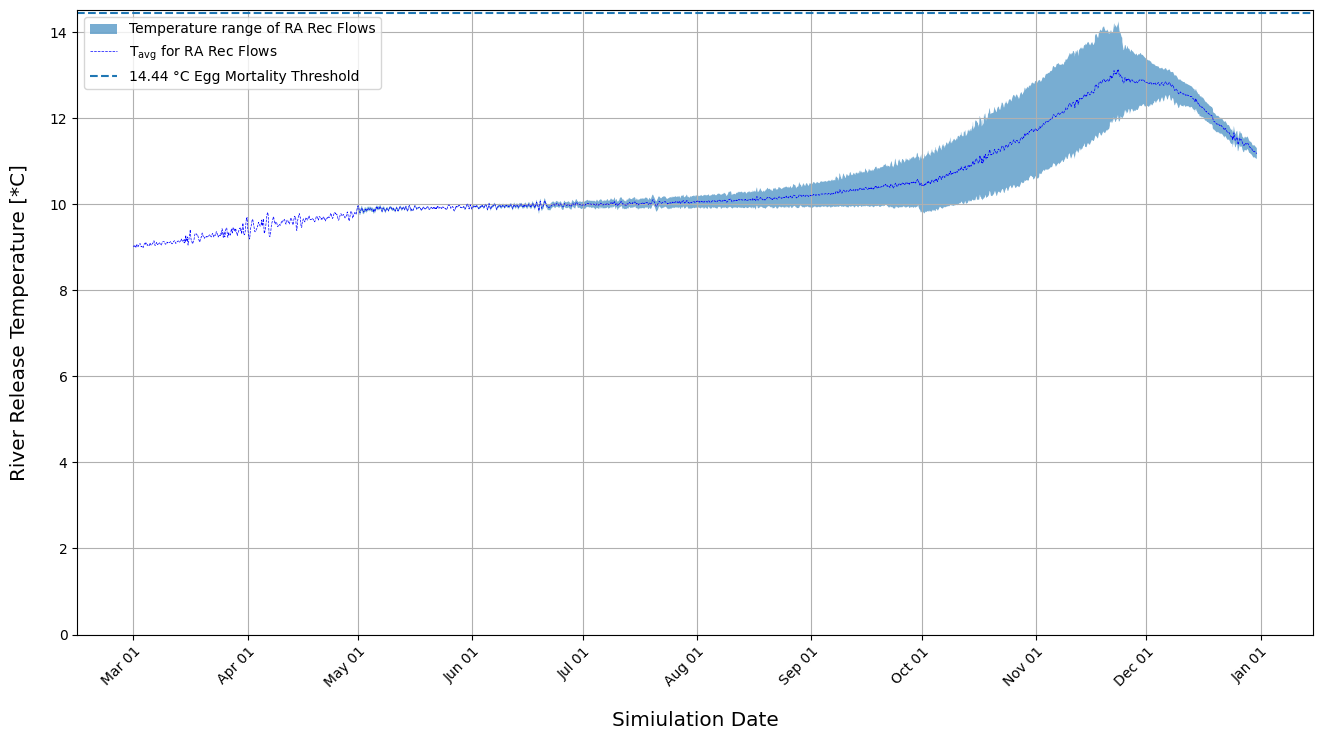

In [29]:

fig, ax = plt.subplots(1, 1, figsize=(13.33, 7.5))
_fig, _ax, tcd_region, tcd_line = mrr_TCD_2024.plot_two_structure_composite(4, ax=ax);

# Modify the labels for the min/max region and average temperature line.
tcd_region.set_label("Temperature range of RA Rec Flows")
tcd_line.set_label(r"$\mathrm{T_{avg}}$ for RA Rec Flows")
tcd_line.set_color("blue")
tcd_line.set(linewidth=0.5)
tcd_line.set_linestyle("--")


# Draw the 14.44°C threshold line
mrr_TCD_2024.plot_threshold_line_y(ax, linestyle="--", label="14.44 °C Egg Mortality Threshold")

# Rotate the x-labels to make it so they don't overlap
xticks, labels = ax.get_xticks(), ax.get_xticklabels()
ax.set_xticks(xticks, labels=labels)
ax.set_xticks(xticks, labels=labels, rotation=45, ha="right", rotation_mode="anchor")

# Resize the axis labels
ax.set_ylabel(ax.get_ylabel(), fontsize="x-large", labelpad=15)
ax.set_xlabel(ax.get_xlabel(), fontsize="x-large", labelpad=15)

#Format x-axis labels to Month(short) and day
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Set y-axis to start at zero
ax.set_ylim(bottom=0)

# Set axis label
ax.set_ylabel("River Release Temperature [*C]")

ax.set_xlabel("Simiulation Date")

# Set grid to show
plt.grid()

# Add a legend to the plot
ax.legend(loc="best")

# Resize the figure to accommodate the changes to axis labels
plt.tight_layout()
#fig.savefig("2026_TCD_flow_comparison.svg")

plt.show()

## Threshold Summary Table

In [31]:
threshold_temperature = 14.44
structure = 4

TCD24_summary = mrr_TCD_2024.threshold_summary(structure, threshold=threshold_temperature)
TCD24_summary["2024 TCD Flows "] = "TCD_24"

df = pd.concat([TCD24_summary])
df

,Tavg [C],Tmin [C],Tmax [C],Days above threshold,2024 TCD Flows
24_TCD_Flow0_1,10.776415,8.99,14.25,0.0,TCD_24
24_TCD_Flow10,10.194423,8.99,12.54,0.0,TCD_24
